//TODO: Add Diane's physical guards in HBVTransition, then you should also be able to set Q=0 for S1_prev

//TODO: Gain of $K = U\text{pinv}(V)$ vs $UV^T [VV^T + R]^{-1}$

//TODO add version of EnsembleKalmanFilter class that has multiplicative and additive input uncertainties, maybe define new KF class that inherits everything from the old one except new prediction function that can handle input errors

After that this should exactly reproduce our results from first project

In [4]:
#!git clone https://github.com/Felix-Schwer/rainfall_kf.git
%cd /content/rainfall_kf
!git pull origin main
!pip uninstall -y rainfall_kf
!pip install -e .

/content/rainfall_kf
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 3), reused 25 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (26/26), 1.22 MiB | 6.37 MiB/s, done.
From https://github.com/Felix-Schwer/rainfall_kf
 * branch            main       -> FETCH_HEAD
   cbfd178..f7ddee2  main       -> origin/main
Updating cbfd178..f7ddee2
Fast-forward
 notebooks/Colab_Notebook.ipynb                     |  147 -
 notebooks/Run_Lorenz_Example_Colab.ipynb           |  198 ++
 rainfall_kf/enkf.py                                |   10 +-
 rainfall_kf/examples/HBV_EDU/.DS_Store             |  Bin 0 -> 6148 bytes
 rainfall_kf/examples/HBV_EDU/10_EduHBV_IJEE.pdf    |  Bin 0 -> 958558 bytes
 rainfall_kf/examples/HBV_EDU/BV.txt                |   10 +
 rainfall_kf/examples/HBV_EDU/IV.txt                |    8 +
 rainfall_kf/examples/HBV_EDU/Qobs.txt              | 3652 ++++++++++++

In [ ]:
import numpy as np

from rainfall_kf.enkf import EnsembleKalmanFilter
from rainfall_kf.examples.hbv_data import read_hbv_initial, read_hbv_inputs, read_hbv_params, read_hbv_qobs
from rainfall_kf.models.hbv import HBVObservation, HBVTransition

np.random.seed(1)

N_STATES = 5
N_OBS = 1
N_ENS = 100

Qassumed = np.diag([2, 2, 0.5, 0.5, 0.5])
Rassumed = np.diag([0.25])

params = read_hbv_params()
inputs_k = read_hbv_inputs()
observations_k = read_hbv_qobs()

iv_values = np.loadtxt("/content/rainfall_kf/rainfall_kf/examples/HBV_EDU/IV.txt", dtype=float, usecols=(1,))
catchment_area = iv_values[0]
observations_mm_day = observations_k * (24 * 3600.0) / (catchment_area * 1000.0)

x0 = read_hbv_initial()
k_steps = inputs_k.shape[1]
times = np.arange(k_steps)

initial_ensemble = x0 + np.linalg.cholesky(Qassumed).T @ np.random.randn(N_STATES, N_ENS)


class HBVTransitionStepper:
    def __init__(self, inputs, params):
        self.inputs = inputs
        self.params = params
        self.step = 0

    def __call__(self, states):
        step_inputs = self.inputs[:, self.step:self.step + 1]
        self.step += 1
        return HBVTransition(states, step_inputs, self.params)

In [14]:
enkf = EnsembleKalmanFilter(
    TransitionEquation=HBVTransitionStepper(inputs_k, params),
    ObservationEquation=lambda states: HBVObservation(states, params),
    Q=Qassumed,
    R=Rassumed
)

result = enkf.run(initial_ensemble=initial_ensemble, times=times, observations=observations_mm_day)

Text(0.5, 0, 'Time step')

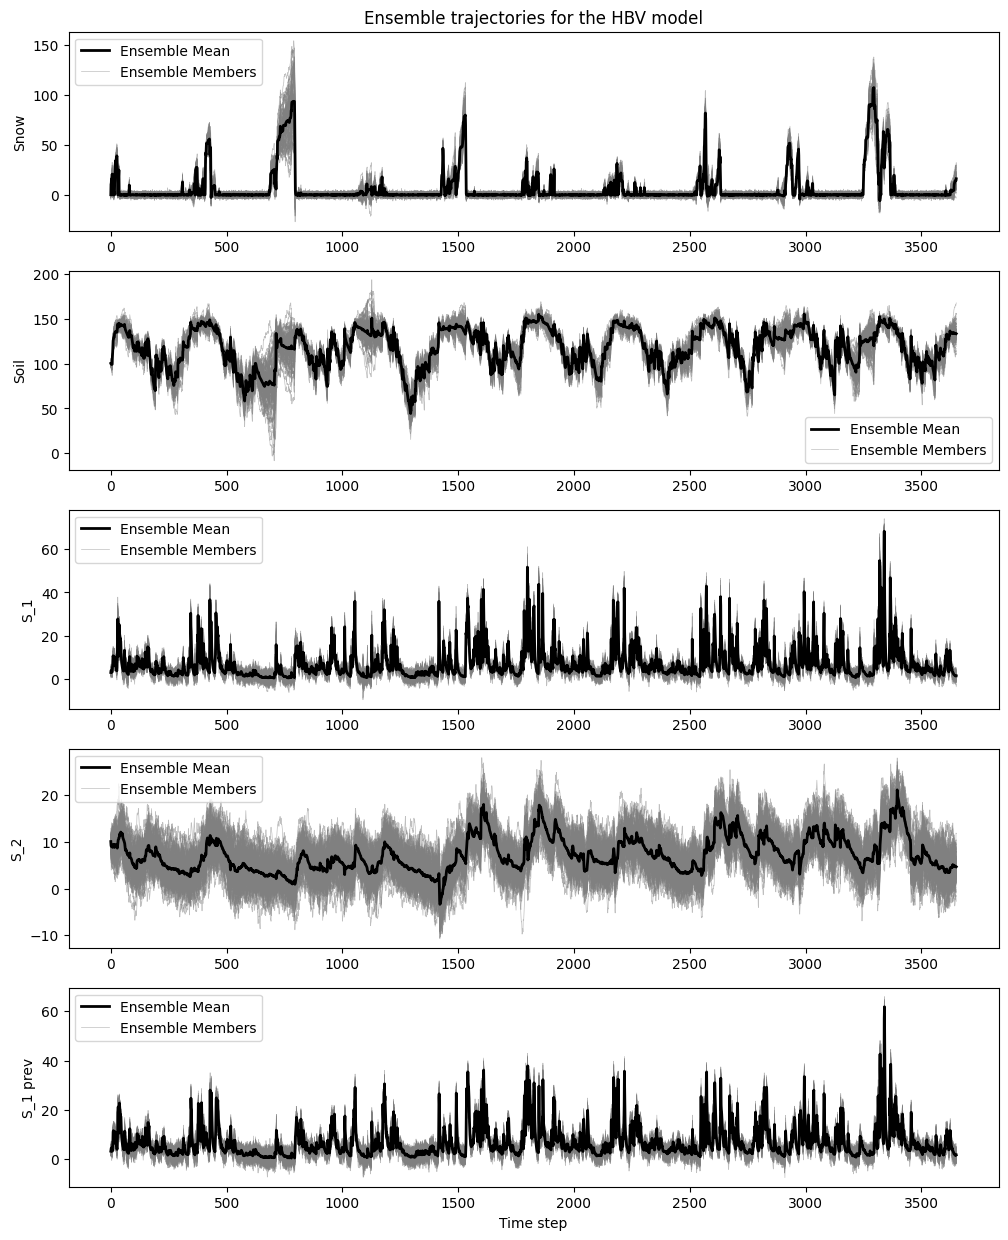

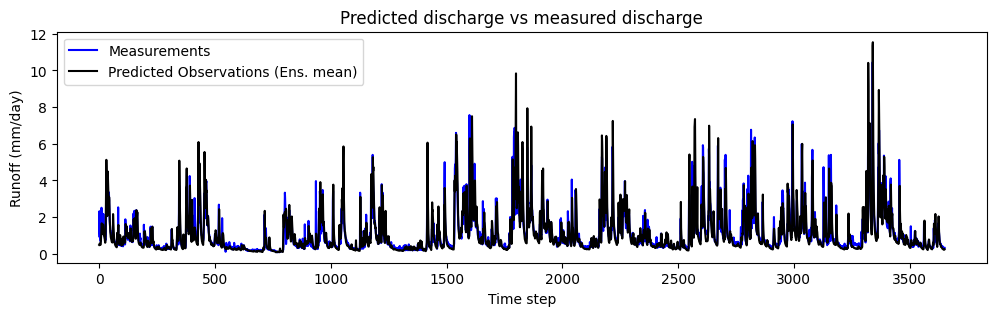

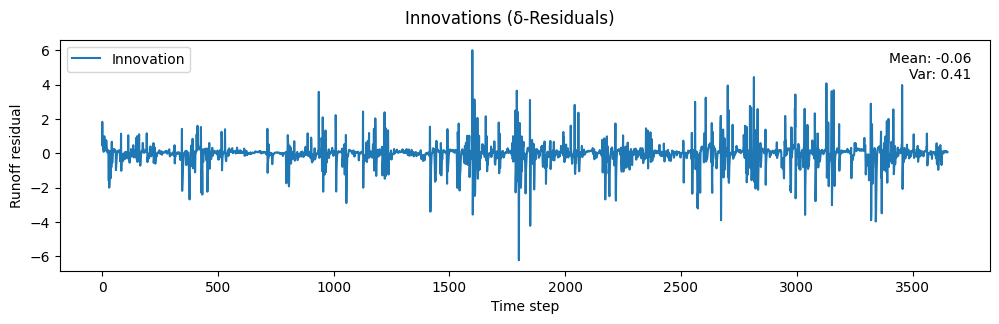

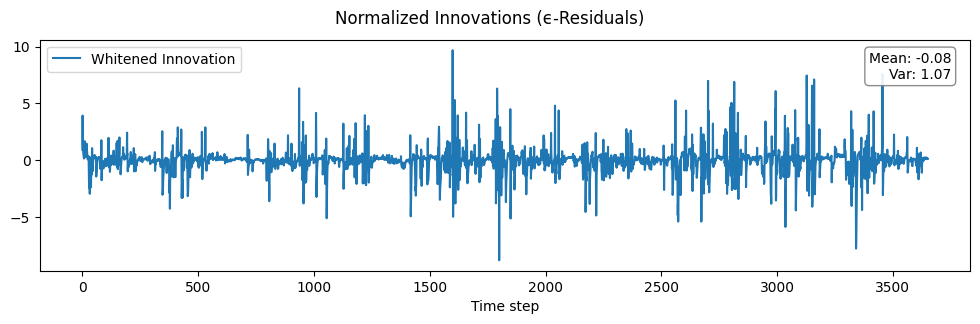

In [16]:
fig = result.plot_ensembles()
axes = fig.get_axes()
axes[0].set_title("Ensemble trajectories for the HBV model")
axes[0].set_ylabel("Snow")
axes[1].set_ylabel("Soil")
axes[2].set_ylabel("S_1")
axes[3].set_ylabel("S_2")
axes[4].set_ylabel("S_1 prev")
axes[4].set_xlabel("Time step")

fig = result.plot_observations()
ax = fig.get_axes()[0]
ax.set_title("Predicted discharge vs measured discharge")
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff (mm/day)")

fig = result.plot_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")
ax.set_ylabel("Runoff residual")

fig = result.plot_whitened_innovations()
ax = fig.get_axes()[0]
ax.set_xlabel("Time step")